In [2]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
!pip install -q transformers datasets evaluate accelerate scikit-learn sentencepiece
!pip install -q matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [3]:
# ============================================================
# CELL 2: Imports & Configuration
# ============================================================
import os, re, random, warnings, math
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from collections import Counter
from datasets import load_dataset, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
from torch.utils.data import DataLoader, Dataset as TorchDataset
warnings.filterwarnings("ignore")

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "xlm-roberta-base"
print(f"Device: {DEVICE}")
print(f"Model:  {MODEL_NAME}")

Device: cuda
Model:  xlm-roberta-base


In [4]:
# ============================================================
# CELL 3: Load & Explore BESSTIE Dataset  (Sarcasm-only)
# ============================================================
from datasets import load_dataset
import numpy as np

ds = load_dataset("unswnlporg/BESSTIE")
print(ds)

# --- Filter: keep ONLY Sarcasm task ---
# --- Sarcasm-only, Reddit-only (paper-aligned) ---
ds_sarc = ds.filter(lambda x: (x["task"] == "Sarcasm") and (x["source"] == "Reddit"))

print("After filtering to Sarcasm + Reddit-only:")
for split_name, split in ds_sarc.items():
    labels = np.array(split["label"])
    unique, counts = np.unique(labels, return_counts=True)
    print(f"Split: {split_name} — rows: {len(split)} — labels: {dict(zip(unique.tolist(), counts.tolist()))}")

from collections import Counter
print("Sources in ds_sarc(train):", Counter(ds_sarc["train"]["source"]))
print("Sources in ds_sarc(val):  ", Counter(ds_sarc["validation"]["source"]))
print("\nSample:", ds_sarc["train"][0])

print("\nAfter filtering to task == 'Sarcasm':")
for split_name, split in ds_sarc.items():
    labels = np.array(split["label"])
    unique, counts = np.unique(labels, return_counts=True)
    print(f"Split: {split_name} — rows: {len(split)} — labels: {dict(zip(unique.tolist(), counts.tolist()))}")

# Preview
print("\n--- Sample (Sarcasm-only) ---")
print(ds_sarc["train"][0])
print("\nColumns:", ds_sarc["train"].column_names)

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/17760 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2428 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'variety', 'source', 'task'],
        num_rows: 17760
    })
    validation: Dataset({
        features: ['text', 'label', 'variety', 'source', 'task'],
        num_rows: 2428
    })
})


Filter:   0%|          | 0/17760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2428 [00:00<?, ? examples/s]

After filtering to Sarcasm + Reddit-only:
Split: train — rows: 4480 — labels: {0: 3288, 1: 1192}
Split: validation — rows: 612 — labels: {0: 449, 1: 163}
Sources in ds_sarc(train): Counter({'Reddit': 4480})
Sources in ds_sarc(val):   Counter({'Reddit': 612})

Sample: {'text': 'This is very helpful, thankyou so much for your reply!', 'label': 0, 'variety': 'en-AU', 'source': 'Reddit', 'task': 'Sarcasm'}

After filtering to task == 'Sarcasm':
Split: train — rows: 4480 — labels: {0: 3288, 1: 1192}
Split: validation — rows: 612 — labels: {0: 449, 1: 163}

--- Sample (Sarcasm-only) ---
{'text': 'This is very helpful, thankyou so much for your reply!', 'label': 0, 'variety': 'en-AU', 'source': 'Reddit', 'task': 'Sarcasm'}

Columns: ['text', 'label', 'variety', 'source', 'task']


In [5]:
# ============================================================
# CELL 4: Tokenize & Train BASELINE Model (Standard Cross-Entropy)
#          ⟳ RESUMABLE: skips training if checkpoint exists
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

# Tokenize all splits
tokenized_ds = ds_sarc.map(tokenize_fn, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro":  f1_score(labels, preds, average="macro"),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall":    recall_score(labels, preds, average="macro", zero_division=0),
    }

# --- Resumable training ---
BASELINE_DIR = "./baseline_model"
BASELINE_BEST = os.path.join(BASELINE_DIR, "best_model")

baseline_args = TrainingArguments(
    output_dir=BASELINE_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

if os.path.exists(BASELINE_BEST):
    print(" BASELINE: Loading from saved checkpoint (skipping training)")
    baseline_model = AutoModelForSequenceClassification.from_pretrained(
        BASELINE_BEST, num_labels=2
    ).to(DEVICE)
    baseline_trainer = Trainer(
        model=baseline_model,
        args=baseline_args,
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
else:
    print("=" * 60)
    print("PHASE 1: Training BASELINE (XLM-RoBERTa + Cross-Entropy)")
    print("=" * 60)
    baseline_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)
    baseline_trainer = Trainer(
        model=baseline_model,
        args=baseline_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Resume from last checkpoint if training was interrupted
    last_ckpt = None
    if os.path.isdir(BASELINE_DIR):
        ckpts = [d for d in os.listdir(BASELINE_DIR) if d.startswith("checkpoint-")]
        if ckpts:
            last_ckpt = os.path.join(
                BASELINE_DIR,
                sorted(ckpts, key=lambda x: int(x.split("-")[1]))[-1]
            )
            print(f"  ⟳ Resuming from {last_ckpt}")

    baseline_trainer.train(resume_from_checkpoint=last_ckpt)

    # Save best model for future re-runs
    baseline_trainer.save_model(BASELINE_BEST)
    tokenizer.save_pretrained(BASELINE_BEST)
    print(f"   Saved best model to {BASELINE_BEST}")

baseline_results = baseline_trainer.evaluate()
print(f"\n{'=' * 60}")
print(f"BASELINE  F1 (macro): {baseline_results['eval_f1_macro']:.4f}")
print(f"BASELINE  Accuracy:   {baseline_results['eval_accuracy']:.4f}")
print(f"{'=' * 60}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/4480 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Saved best model to ./baseline_model/best_model



BASELINE  F1 (macro): 0.5837
BASELINE  Accuracy:   0.7467


In [6]:
# ============================================================
# CELL 5: Data Augmentation Pipeline
# ============================================================
PROTECT_WORDS = {"not", "no", "never", "none", "n't", "nothing", "nowhere"}

SPELLING_MAP = {
    "colour": "color", "favourite": "favorite", "favour": "favor",
    "organise": "organize", "organised": "organized", "organising": "organizing",
    "apologise": "apologize", "travelling": "traveling", "traveller": "traveler",
    "centre": "center", "theatre": "theater", "litre": "liter", "metre": "meter",
    "cheque": "check", "mum": "mom", "tyre": "tire",
}

CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "it's": "it is", "i'm": "i am",
    "i've": "i have", "i'll": "i will", "you're": "you are",
    "we're": "we are", "they're": "they are", "that's": "that is",
}
CONTRACTIONS_INV = {v: k for k, v in CONTRACTIONS.items()}

def _preserve_case(src, dst):
    if src.isupper(): return dst.upper()
    if src[0:1].isupper(): return dst.capitalize()
    return dst

def spelling_swap(text, p=0.12):
    def repl(m):
        w = m.group(0); low = w.lower()
        if low in SPELLING_MAP and random.random() < p:
            return _preserve_case(w, SPELLING_MAP[low])
        return w
    return re.sub(r"\b[A-Za-z']+\b", repl, text)

def contractions_toggle(text, p=0.10):
    def expand(m):
        w = m.group(0); low = w.lower()
        if low in CONTRACTIONS and random.random() < p:
            return _preserve_case(w, CONTRACTIONS[low])
        return w
    out = re.sub(r"\b[A-Za-z']+\b", expand, text)
    for full, contr in CONTRACTIONS_INV.items():
        if random.random() < p:
            out = re.sub(rf"\b{re.escape(full)}\b", contr, out, flags=re.IGNORECASE)
    return out

def light_noise(text, p=0.08):
    protect = any(w in text.lower() for w in PROTECT_WORDS)
    out = text
    if random.random() < p:
        out = re.sub(r"([!.?])", r"\1\1", out, count=1)
    if random.random() < p and not protect:
        out = re.sub(
            r"\b(so|very|really|too)\b",
            lambda m: m.group(0) + "o",
            out,
            flags=re.IGNORECASE,
            count=1
        )
    return out

def augment_text(text):
    out = text
    if random.random() < 0.35: out = spelling_swap(out)
    if random.random() < 0.35: out = contractions_toggle(out)
    if random.random() < 0.25: out = light_noise(out)
    return out

# --- Build class-balanced augmented training set ---
train_data = ds_sarc["train"]
labels = np.array(train_data["label"])
unique, counts = np.unique(labels, return_counts=True)
label_counts = dict(zip(unique.tolist(), counts.tolist()))
print(f"Original class distribution: {label_counts}")

maj_label = max(label_counts, key=label_counts.get)
min_label = min(label_counts, key=label_counts.get)
gap = label_counts[maj_label] - label_counts[min_label]

# Augment minority to balance
minority_indices = [i for i, l in enumerate(labels) if l == min_label]
aug_rows = []
for _ in range(gap):
    idx = random.choice(minority_indices)
    ex = train_data[idx]
    aug_rows.append({"text": augment_text(ex["text"]), "label": ex["label"]})

# Also augment ALL samples once for diversity
for i in range(len(train_data)):
    ex = train_data[i]
    aug_rows.append({"text": augment_text(ex["text"]), "label": ex["label"]})

# Combine
original_rows = [{"text": ex["text"], "label": ex["label"]} for ex in train_data]
all_rows = original_rows + aug_rows
random.shuffle(all_rows)

aug_train_ds = Dataset.from_list(all_rows)
aug_train_tok = aug_train_ds.map(tokenize_fn, batched=True)
print(f"Augmented training set size: {len(aug_train_ds)}")
print(f"  Original: {len(original_rows)}")
print(f"  Augmented: {len(aug_rows)} (balance: {gap} + diversity: {len(train_data)})")

Original class distribution: {0: 3288, 1: 1192}


Map:   0%|          | 0/11056 [00:00<?, ? examples/s]

Augmented training set size: 11056
  Original: 4480
  Augmented: 6576 (balance: 2096 + diversity: 4480)


In [7]:
# ============================================================
# CELL 6: Train AUGMENTED BASELINE (Augmentation + Cross-Entropy)
#          ⟳ RESUMABLE: skips training if checkpoint exists
# ============================================================
AUG_DIR = "./aug_baseline_model"
AUG_BEST = os.path.join(AUG_DIR, "best_model")

aug_baseline_args = TrainingArguments(
    output_dir=AUG_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

if os.path.exists(AUG_BEST):
    print(" AUG BASELINE: Loading from saved checkpoint (skipping training)")
    aug_baseline_model = AutoModelForSequenceClassification.from_pretrained(
        AUG_BEST, num_labels=2
    ).to(DEVICE)
    aug_baseline_trainer = Trainer(
        model=aug_baseline_model,
        args=aug_baseline_args,
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
else:
    print("=" * 60)
    print("PHASE 2: Training AUGMENTED BASELINE (Data Aug + Cross-Entropy)")
    print("=" * 60)
    aug_baseline_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)
    aug_baseline_trainer = Trainer(
        model=aug_baseline_model,
        args=aug_baseline_args,
        train_dataset=aug_train_tok,
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Resume from last checkpoint if interrupted
    last_ckpt = None
    if os.path.isdir(AUG_DIR):
        ckpts = [d for d in os.listdir(AUG_DIR) if d.startswith("checkpoint-")]
        if ckpts:
            last_ckpt = os.path.join(
                AUG_DIR,
                sorted(ckpts, key=lambda x: int(x.split("-")[1]))[-1]
            )
            print(f"  ⟳ Resuming from {last_ckpt}")

    aug_baseline_trainer.train(resume_from_checkpoint=last_ckpt)
    aug_baseline_trainer.save_model(AUG_BEST)
    tokenizer.save_pretrained(AUG_BEST)
    print(f"   Saved best model to {AUG_BEST}")

aug_baseline_results = aug_baseline_trainer.evaluate()
print(f"\n{'=' * 60}")
print(f"AUG BASELINE  F1 (macro): {aug_baseline_results['eval_f1_macro']:.4f}")
print(f"AUG BASELINE  Accuracy:   {aug_baseline_results['eval_accuracy']:.4f}")
print(f"{'=' * 60}")

PHASE 2: Training AUGMENTED BASELINE (Data Aug + Cross-Entropy)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.643902,0.499864,0.763072,0.698630,0.697512,0.699803
2,0.460636,0.695879,0.772876,0.695166,0.707052,0.686946
3,0.172621,1.059046,0.769608,0.665875,0.703704,0.651502


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Saved best model to ./aug_baseline_model/best_model



AUG BASELINE  F1 (macro): 0.6986
AUG BASELINE  Accuracy:   0.7631


In [9]:
# ============================================================
# CELL 7: Define Contrastive Learning Model
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al. 2020).
    For each anchor, pulls same-label samples closer and pushes
    different-label samples further in embedding space.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        batch_size = features.shape[0]

        # Similarity matrix: (B, B)
        sim_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: same label = 1, different = 0, diagonal = 0
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # Remove self-comparison
        self_mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        mask = mask.masked_fill(self_mask, 0)

        # Count positives per anchor
        num_positives = mask.sum(dim=1)

        # For numerical stability, subtract max
        logits_max, _ = sim_matrix.max(dim=1, keepdim=True)
        logits = sim_matrix - logits_max.detach()

        # Mask out self from denominator
        logits = logits.masked_fill(self_mask, float("-inf"))

        exp_logits = torch.exp(logits)
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-10)

        mean_log_prob = (mask * log_prob).sum(dim=1) / (num_positives + 1e-10)

        valid = num_positives > 0
        loss = -mean_log_prob[valid].mean()

        if torch.isnan(loss):
            return torch.tensor(0.0, device=device)
        return loss


class XLMRContrastiveModel(nn.Module):
    """
    XLM-RoBERTa with dual heads:
    1. Projection head for contrastive learning (CLS → 256 → 128)
    2. Classification head for sarcasm detection (CLS → 2)
    """
    def __init__(self, model_name, num_labels=2, projection_dim=128, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size  # 768 for xlm-roberta-base

        # Projection head for contrastive learning
        self.projection_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, projection_dim),
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_labels),
        )
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # CLS token

        # Projection (L2-normalized for contrastive)
        projections = self.projection_head(cls_embedding)
        projections = F.normalize(projections, p=2, dim=1)

        # Classification
        logits = self.classifier(cls_embedding)

        return {
            "logits": logits,
            "projections": projections,
            "cls_embedding": cls_embedding,
        }

print(" SupConLoss and XLMRContrastiveModel defined")
print(f"   Architecture: {MODEL_NAME} → CLS (768) → Projection (128) + Classifier (2)")

 SupConLoss and XLMRContrastiveModel defined
   Architecture: xlm-roberta-base → CLS (768) → Projection (128) + Classifier (2)


In [10]:
# ============================================================
# CELL 8: Custom Trainer with Combined Loss
# ============================================================
class ContrastiveTrainer(Trainer):
    """
    Custom Trainer that computes:
        L = alpha * L_supcon + (1 - alpha) * L_cross_entropy
    """
    def __init__(self, *args, alpha=0.3, temperature=0.07, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.supcon_loss = SupConLoss(temperature=temperature)
        self.ce_loss = nn.CrossEntropyLoss()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
        )
        logits = outputs["logits"]
        projections = outputs["projections"]

        # Cross-entropy loss
        loss_ce = self.ce_loss(logits, labels)

        # Supervised contrastive loss
        loss_scl = self.supcon_loss(projections, labels)

        # Combined loss
        loss = self.alpha * loss_scl + (1 - self.alpha) * loss_ce
        return (loss, outputs) if return_outputs else loss

print(f" ContrastiveTrainer defined")
print(f"   Loss = α × SupConLoss + (1-α) × CrossEntropyLoss")
print(f"   Default α = 0.3, temperature τ = 0.07")

 ContrastiveTrainer defined
   Loss = α × SupConLoss + (1-α) × CrossEntropyLoss
   Default α = 0.3, temperature τ = 0.07


In [11]:
# ============================================================
# CELL 9: Metrics wrapper for contrastive model output
# ============================================================
def compute_metrics_contrastive(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        logits = predictions[0]
    else:
        logits = predictions
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro":  f1_score(labels, preds, average="macro"),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall":    recall_score(labels, preds, average="macro", zero_division=0),
    }
print(" Metrics function ready")

# --- Free GPU memory from previous models ---
import gc
for _var in ['baseline_model', 'baseline_trainer', 'aug_baseline_model', 'aug_baseline_trainer']:
    if _var in globals(): del globals()[_var]
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed. Currently used: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

 Metrics function ready
GPU memory freed. Currently used: 6.26 GB


In [12]:
# ============================================================
# CELL 10: Train Contrastive Learning Model (Our Extension)
#           ⟳ RESUMABLE: skips training if checkpoint exists
# ============================================================
CON_DIR = "./contrastive_model"
CON_BEST = os.path.join(CON_DIR, "best_model")

contrastive_args = TrainingArguments(
    output_dir=CON_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,   # Reduced to fit GPU memory
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

if os.path.exists(CON_BEST):
    print(" CONTRASTIVE: Loading from saved checkpoint (skipping training)")
    contrastive_model = XLMRContrastiveModel(
        model_name=MODEL_NAME, num_labels=2, projection_dim=128, dropout=0.1
    ).to(DEVICE)
    state_dict = torch.load(os.path.join(CON_BEST, "model.pt"), map_location=DEVICE)
    contrastive_model.load_state_dict(state_dict)
    contrastive_model.eval()
    contrastive_trainer = ContrastiveTrainer(
        model=contrastive_model,
        args=contrastive_args,
        alpha=0.3,
        temperature=0.07,
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics_contrastive,
    )
else:
    print("=" * 60)
    print("PHASE 3: Training CONTRASTIVE MODEL (SupCon + CE + Augmentation)")
    print("=" * 60)
    contrastive_model = XLMRContrastiveModel(
        model_name=MODEL_NAME, num_labels=2, projection_dim=128, dropout=0.1
    ).to(DEVICE)
    contrastive_trainer = ContrastiveTrainer(
        model=contrastive_model,
        args=contrastive_args,
        alpha=0.3,
        temperature=0.07,
        train_dataset=aug_train_tok,
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics_contrastive,
    )

    # Resume from last checkpoint if interrupted
    last_ckpt = None
    if os.path.isdir(CON_DIR):
        ckpts = [d for d in os.listdir(CON_DIR) if d.startswith("checkpoint-")]
        if ckpts:
            last_ckpt = os.path.join(
                CON_DIR,
                sorted(ckpts, key=lambda x: int(x.split("-")[1]))[-1]
            )
            print(f"  ⟳ Resuming from {last_ckpt}")

    contrastive_trainer.train(resume_from_checkpoint=last_ckpt)

    # Save custom model (nn.Module, not HF model — need torch.save)
    os.makedirs(CON_BEST, exist_ok=True)
    torch.save(contrastive_model.state_dict(), os.path.join(CON_BEST, "model.pt"))
    print(f"   Saved contrastive model to {CON_BEST}")

contrastive_results = contrastive_trainer.evaluate()
print(f"\n{'=' * 60}")
print(f"CONTRASTIVE  F1 (macro): {contrastive_results['eval_f1_macro']:.4f}")
print(f"CONTRASTIVE  Accuracy:   {contrastive_results['eval_accuracy']:.4f}")
print(f"{'=' * 60}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


PHASE 3: Training CONTRASTIVE MODEL (SupCon + CE + Augmentation)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.456519,0.378132,0.758170,0.638621,0.684776,0.626122
2,0.315974,0.562762,0.746732,0.648946,0.667108,0.639820
3,0.085529,1.097255,0.753268,0.614717,0.677151,0.605196
4,0.040779,1.281910,0.756536,0.635153,0.681807,0.623055


   Saved contrastive model to ./contrastive_model/best_model



CONTRASTIVE  F1 (macro): 0.6489
CONTRASTIVE  Accuracy:   0.7467


In [13]:
# --- Reload models from checkpoints (they were deleted to free GPU) ---
import gc

# Reload baseline
BASELINE_BEST = "./baseline_model/best_model"
baseline_model = AutoModelForSequenceClassification.from_pretrained(BASELINE_BEST).to(DEVICE)
baseline_trainer = Trainer(
    model=baseline_model,
    args=TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=32, report_to="none"),
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Reload augmented baseline
AUG_BEST = "./aug_baseline_model/best_model"
aug_baseline_model = AutoModelForSequenceClassification.from_pretrained(AUG_BEST).to(DEVICE)
aug_baseline_trainer = Trainer(
    model=aug_baseline_model,
    args=TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=32, report_to="none"),
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(" All 3 models loaded for comparison")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 All 3 models loaded for comparison


In [14]:
# ============================================================
# CELL 12: Comprehensive Comparison
# ============================================================

# --- Get predictions from all 3 models ---
print("Generating predictions from all models.")

pred_base = baseline_trainer.predict(tokenized_ds["validation"])
pred_aug  = aug_baseline_trainer.predict(tokenized_ds["validation"])
pred_con  = contrastive_trainer.predict(tokenized_ds["validation"])

y_true = pred_base.label_ids
y_pred_base = np.argmax(pred_base.predictions, axis=1)
y_pred_aug  = np.argmax(pred_aug.predictions, axis=1)

# Contrastive model may return tuple
con_logits = pred_con.predictions[0] if isinstance(pred_con.predictions, tuple) else pred_con.predictions
y_pred_con = np.argmax(con_logits, axis=1)

# --- Build comparison table ---
def get_all_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

comparison = pd.DataFrame([
    get_all_metrics(y_true, y_pred_base, "Baseline (CE only)"),
    get_all_metrics(y_true, y_pred_aug,  "Augmented (CE + Aug)"),
    get_all_metrics(y_true, y_pred_con,  "Contrastive (SupCon + CE + Aug)"),
])

# Add improvement columns
for col in ["F1 (macro)", "Accuracy", "Precision", "Recall"]:
    base_val = comparison.loc[0, col]
    comparison[f"Δ {col}"] = comparison[col] - base_val

print("\n" + "=" * 80)
print("FINAL COMPARISON: Baseline vs Augmented vs Contrastive")
print("=" * 80)
print(comparison[["Model", "F1 (macro)", "Accuracy", "Precision", "Recall"]].to_string(index=False))
print()
print("Improvement over Baseline:")
print(comparison[["Model", "Δ F1 (macro)", "Δ Accuracy"]].to_string(index=False))

Generating predictions from all models.



FINAL COMPARISON: Baseline vs Augmented vs Contrastive
                          Model  F1 (macro)  Accuracy  Precision   Recall
             Baseline (CE only)    0.583683  0.746732   0.664918 0.581203
           Augmented (CE + Aug)    0.698630  0.763072   0.697512 0.699803
Contrastive (SupCon + CE + Aug)    0.648946  0.746732   0.667108 0.639820

Improvement over Baseline:
                          Model  Δ F1 (macro)  Δ Accuracy
             Baseline (CE only)      0.000000     0.00000
           Augmented (CE + Aug)      0.114947     0.01634
Contrastive (SupCon + CE + Aug)      0.065264     0.00000


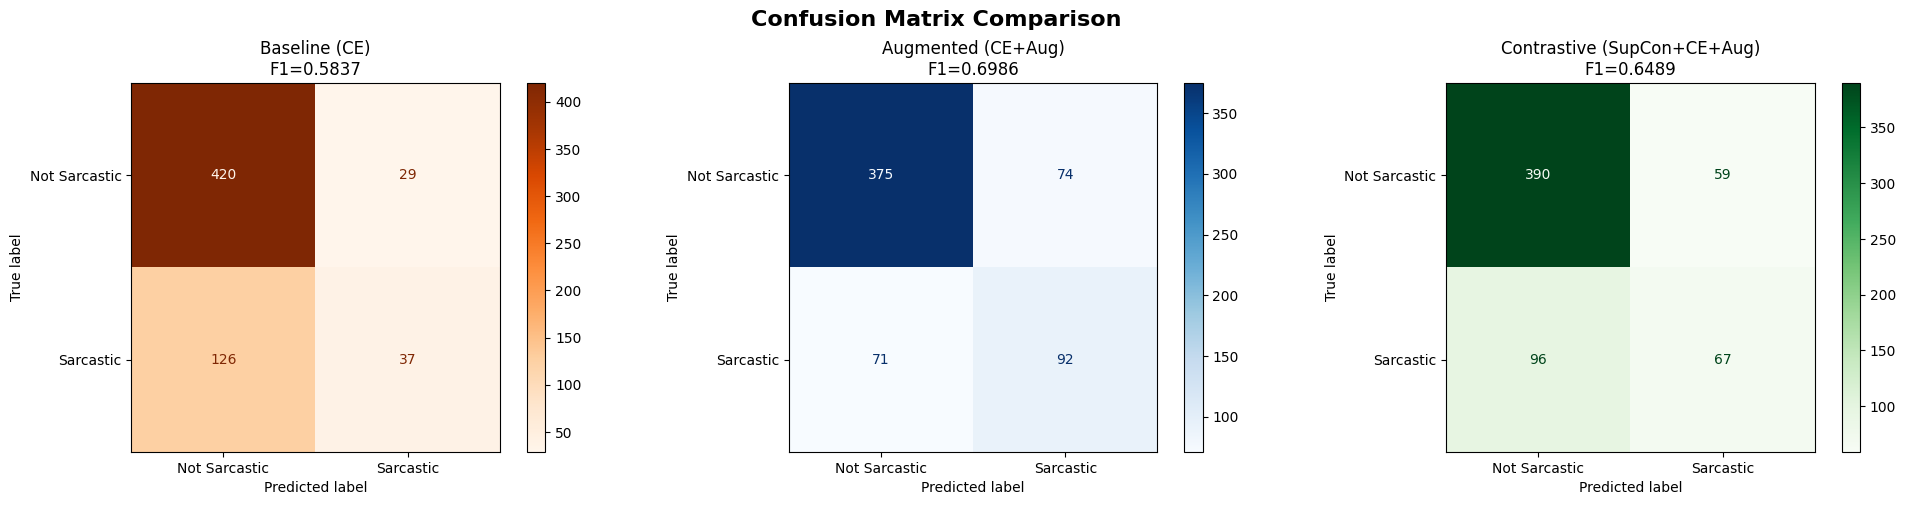

In [15]:
# ============================================================
# CELL 13: Side-by-Side Confusion Matrices
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

names = ["Baseline (CE)", "Augmented (CE+Aug)", "Contrastive (SupCon+CE+Aug)"]
preds_list = [y_pred_base, y_pred_aug, y_pred_con]
colors = ["Oranges", "Blues", "Greens"]

for ax, y_pred, name, cmap in zip(axes, preds_list, names, colors):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not Sarcastic", "Sarcastic"]).plot(
        ax=ax, cmap=cmap
    )
    f1 = f1_score(y_true, y_pred, average="macro")
    ax.set_title(f"{name}\nF1={f1:.4f}", fontsize=12)

plt.suptitle("Confusion Matrix Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Extracting embeddings (this may take a minute)...
Running t-SNE...


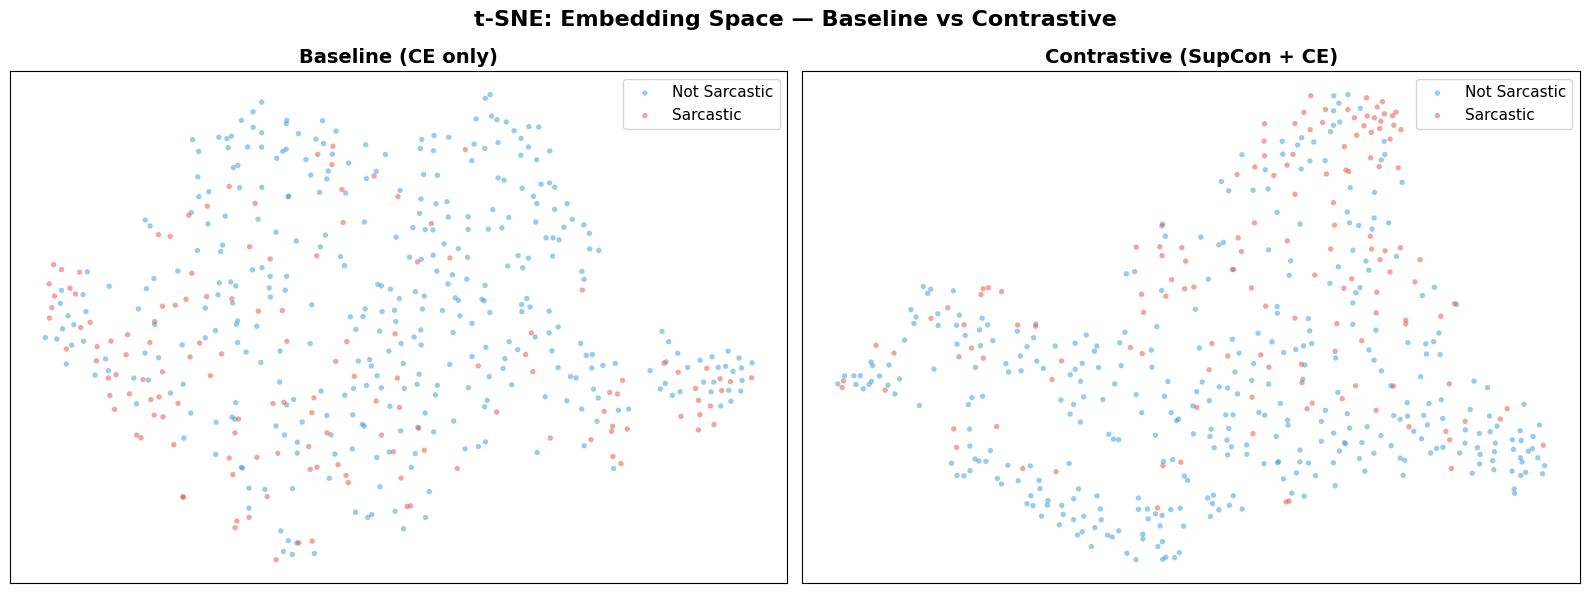


→ The contrastive model should show tighter, more separated clusters.
  This means the model has learned a clearer distinction between sarcasm and non-sarcasm.


In [16]:
# ============================================================
# CELL 14: t-SNE Embedding Visualization
# ============================================================
from sklearn.manifold import TSNE

def extract_embeddings(model, dataset, max_samples=500, is_contrastive=False):
    """Extract CLS embeddings from a model for visualization."""
    model.eval()
    embeddings = []
    labels_out = []

    indices = list(range(min(max_samples, len(dataset))))
    random.shuffle(indices)

    with torch.no_grad():
        for i in indices:
            sample = dataset[i]
            input_ids = torch.tensor([sample["input_ids"]]).to(DEVICE)
            attention_mask = torch.tensor([sample["attention_mask"]]).to(DEVICE)

            if is_contrastive:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                emb = outputs["projections"].cpu().numpy()[0]
            else:
                # HF sequence classification models typically have .roberta backbone
                outputs = model.roberta(input_ids=input_ids, attention_mask=attention_mask)
                emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]

            embeddings.append(emb)
            labels_out.append(sample["label"])

    return np.array(embeddings), np.array(labels_out)

print("Extracting embeddings (this may take a minute)...")
emb_base, lab_base = extract_embeddings(baseline_model, tokenized_ds["validation"], is_contrastive=False)
emb_con, lab_con   = extract_embeddings(contrastive_model, tokenized_ds["validation"], is_contrastive=True)

print("Running t-SNE...")
tsne_base = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(emb_base)
tsne_con  = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(emb_con)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
label_names = {0: "Not Sarcastic", 1: "Sarcastic"}
palette = {0: "#3498db", 1: "#e74c3c"}

for ax, tsne, lab, title in [
    (axes[0], tsne_base, lab_base, "Baseline (CE only)"),
    (axes[1], tsne_con,  lab_con,  "Contrastive (SupCon + CE)"),
]:
    for lbl in [0, 1]:
        mask = lab == lbl
        ax.scatter(
            tsne[mask, 0], tsne[mask, 1],
            c=palette[lbl], label=label_names[lbl],
            alpha=0.5, s=15, edgecolors="none"
        )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    "t-SNE: Embedding Space — Baseline vs Contrastive",
    fontsize=16, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("\n→ The contrastive model should show tighter, more separated clusters.")
print("  This means the model has learned a clearer distinction between sarcasm and non-sarcasm.")

In [17]:
# ============================================================
# CELL 15: Error Analysis — What Did Contrastive Fix?
# ============================================================

# Samples fixed by contrastive vs baseline
fixed  = (y_pred_base != y_true) & (y_pred_con == y_true)
broken = (y_pred_base == y_true) & (y_pred_con != y_true)

# Samples fixed by contrastive vs augmented
fixed_vs_aug  = (y_pred_aug != y_true) & (y_pred_con == y_true)
broken_vs_aug = (y_pred_aug == y_true) & (y_pred_con != y_true)

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(f"\nContrastive vs Baseline:")
print(f" Fixed: {fixed.sum()} samples (were wrong, now correct)")
print(f" Broken: {broken.sum()} samples (were correct, now wrong)")
print(f" Net: +{fixed.sum() - broken.sum()} samples improved")

print(f"\nContrastive vs Augmented Baseline:")
print(f" Fixed: {fixed_vs_aug.sum()} samples")
print(f" Broken: {broken_vs_aug.sum()} samples")
print(f" Net: +{fixed_vs_aug.sum() - broken_vs_aug.sum()} samples improved")

# Show examples of fixed predictions
if fixed.sum() > 0:
    print(f"\n--- Examples Fixed by Contrastive (vs Baseline) ---")
    fixed_idx = np.where(fixed)[0][:8]
    for idx in fixed_idx:
        text = tokenized_ds["validation"][int(idx)]["text"]
        label_str = "Sarcastic" if y_true[idx] == 1 else "Not Sarcastic"
        print(f" [{label_str}] {text[:100]}...")
        print(f" Baseline: {y_pred_base[idx]} Contrastive: {y_pred_con[idx]} ")
        print()

ERROR ANALYSIS

Contrastive vs Baseline:
 Fixed: 47 samples (were wrong, now correct)
 Broken: 47 samples (were correct, now wrong)
 Net: +0 samples improved

Contrastive vs Augmented Baseline:
 Fixed: 49 samples
 Broken: 59 samples
 Net: +-10 samples improved

--- Examples Fixed by Contrastive (vs Baseline) ---
 [Not Sarcastic] How insulated are they?  I'm over paper thin walls....
 Baseline: 1 Contrastive: 0 

 [Sarcastic] The Decepticons are infiltrating and taking over...
 Baseline: 0 Contrastive: 1 

 [Sarcastic] Absolute storm in a tea cup....
 Baseline: 0 Contrastive: 1 

 [Sarcastic] Victoria's debt perhaps?!...
 Baseline: 0 Contrastive: 1 

 [Sarcastic] I'm sure all the high beamers will read this and be ashamed....
 Baseline: 0 Contrastive: 1 

 [Sarcastic] If it's being genuine yes.
The issue is they aren't
they are stealing from the GOP playbook,block an...
 Baseline: 0 Contrastive: 1 

 [Sarcastic] Your REA should be providng guidance on how to resolve this issue lol. But 

In [18]:
# ============================================================
# CELL 16: Saliency Comparison — Baseline vs Contrastive on Fixed Samples
# ============================================================

from IPython.display import display, HTML

def compute_saliency(text, model, tokenizer, is_contrastive=False):
    """
    Compute input × gradient saliency for each token.
    Works for both standard HF models and our custom contrastive model.
    Returns: list of (token, score), predicted_class, probabilities
    """
    model.eval()
    model.zero_grad()

    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=256
    ).to(DEVICE)

    if is_contrastive:
        # Our custom model: get embeddings manually
        embed_layer = model.encoder.get_input_embeddings()
        embed_out = embed_layer(inputs["input_ids"])
        embed_out.retain_grad()

        encoder_out = model.encoder(
            inputs_embeds=embed_out,
            attention_mask=inputs["attention_mask"],
        )
        cls_emb = encoder_out.last_hidden_state[:, 0, :]
        logits = model.classifier(cls_emb)
    else:
        # Standard HF model
        embed_layer = model.get_input_embeddings()
        embed_out = embed_layer(inputs["input_ids"])
        embed_out.retain_grad()

        outputs = model(
            inputs_embeds=embed_out,
            attention_mask=inputs["attention_mask"],
        )
        logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)
    pred_class = logits.argmax(dim=-1).item()

    # Backward on predicted class
    logits[0, pred_class].backward()

    # Saliency = |embedding × gradient|, summed over hidden dim
    grads = embed_out.grad[0]
    saliency = (embed_out[0] * grads).abs().sum(dim=-1).detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())
    return list(zip(tokens, saliency)), pred_class, probs[0].detach().cpu().numpy()


def render_saliency_html(text, model, tokenizer, true_label, model_name, is_contrastive=False):
    """
    Create color-coded HTML visualization of token saliency.
    Red = high influence, light = low influence.
    """
    token_scores, pred_class, probs = compute_saliency(text, model, tokenizer, is_contrastive)

    scores = np.array([s for _, s in token_scores])
    if scores.max() > 0:
        scores = scores / scores.max()

    label_map = {0: "Not Sarcastic", 1: "Sarcastic"}
    pred_str = label_map.get(pred_class, str(pred_class))
    true_str = label_map.get(true_label, "?")  # (non usato, ma nel notebook c'è)

    icon = "✅" if pred_class == true_label else "❌"

    html = (
        f'<div style="font-family:monospace; padding:8px; background:#f8f8f8; '
        f'border-radius:6px; margin:3px 0;">'
    )
    html += (
        f'<b>{model_name}</b> → Pred: <b>{pred_str}</b> ({probs[pred_class]:.1%}) '
        f'{icon}<br>'
    )

    for (token, _), score in zip(token_scores, scores):
        if token in ("<s>", "</s>", "<pad>"):
            continue

        r = int(255 * score)
        g = int(255 * (1 - score) * 0.8)
        b = int(100 * (1 - score))

        bg = f"rgba({r},{g},{b},0.2)"
        color = f"rgb({r},{g},{b})"

        clean = token.replace("▁", " ")
        html += (
            f'<span style="color:{color}; background:{bg}; padding:1px 3px; '
            f'border-radius:3px;" title="saliency: {score:.3f}">{clean}</span>'
        )

    html += "</div>"
    return html


# --- Pick samples: misclassified by baseline, fixed by contrastive ---
fixed_mask = (y_pred_base != y_true) & (y_pred_con == y_true)
fixed_indices = np.where(fixed_mask)[0]

if len(fixed_indices) == 0:
    print("No samples were fixed by the contrastive model — showing random misclassified samples instead.")
    fixed_indices = np.where(y_pred_base != y_true)[0]

# Take up to 8 samples
sample_indices = fixed_indices[:8]

html_out = "<h3>\n Saliency: Baseline (top) vs Contrastive (bottom)</h3>"
html_out += '<p style="color:#555;">Red tokens = high influence on prediction. '
html_out += "Hover for exact scores. These are samples the baseline got <b>wrong</b> "
html_out += "but contrastive got <b>right</b>.</p>"

for idx in sample_indices:
    # Nota: nel PDF questa riga usa tokenized_ds["validation"][...]["text"]
    # Se nel tuo tokenized_ds non c'è più 'text', cambia a ds["validation"][...]["text"]
    text = tokenized_ds["validation"][int(idx)]["text"]
    true_label = int(y_true[idx])
    label_str = "Sarcastic" if true_label == 1 else "Not Sarcastic"

    html_out += (
        '<div style="margin:12px 0; padding:10px; border:2px solid #ddd; '
        'border-radius:10px;">'
    )
    html_out += f"<b>Sample {int(idx)}</b> — True: <b>{label_str}</b><br>"
    html_out += f'<i>"{text[:150]}{"..." if len(text) > 150 else ""}"</i><br><br>'

    # Baseline saliency
    html_out += render_saliency_html(
        text, baseline_model, tokenizer, true_label,
        "Baseline (CE)", is_contrastive=False
    )

    # Contrastive saliency
    html_out += render_saliency_html(
        text, contrastive_model, tokenizer, true_label,
        "Contrastive (SupCon+CE)", is_contrastive=True
    )

    html_out += "</div>"

display(HTML(html_out))

print(f"\nShowing {len(sample_indices)} samples where Baseline was WRONG but Contrastive was CORRECT.")
print("→ Compare which tokens each model focuses on — the contrastive model should")
print("  attend more to sarcasm-relevant cues (intensifiers, contrast, punctuation).")


Showing 8 samples where Baseline was WRONG but Contrastive was CORRECT.
→ Compare which tokens each model focuses on — the contrastive model should
  attend more to sarcasm-relevant cues (intensifiers, contrast, punctuation).


In [19]:
# ============================================================
# CELL 17: Per-Class Performance Comparison
# ============================================================
print("\n" + "=" * 60)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 60)

target_names = ["Not Sarcastic (0)", "Sarcastic (1)"]

print("\n--- Baseline ---")
print(classification_report(y_true, y_pred_base, target_names=target_names))

print("--- Augmented Baseline ---")
print(classification_report(y_true, y_pred_aug, target_names=target_names))

print("--- Contrastive (Our Extension) ---")
print(classification_report(y_true, y_pred_con, target_names=target_names))


PER-CLASS CLASSIFICATION REPORT

--- Baseline ---
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.77      0.94      0.84       449
    Sarcastic (1)       0.56      0.23      0.32       163

         accuracy                           0.75       612
        macro avg       0.66      0.58      0.58       612
     weighted avg       0.71      0.75      0.71       612

--- Augmented Baseline ---
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.84      0.84      0.84       449
    Sarcastic (1)       0.55      0.56      0.56       163

         accuracy                           0.76       612
        macro avg       0.70      0.70      0.70       612
     weighted avg       0.76      0.76      0.76       612

--- Contrastive (Our Extension) ---
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.80      0.87      0.83       449
    Sarcastic (1)       0.53      0.41      0.46     

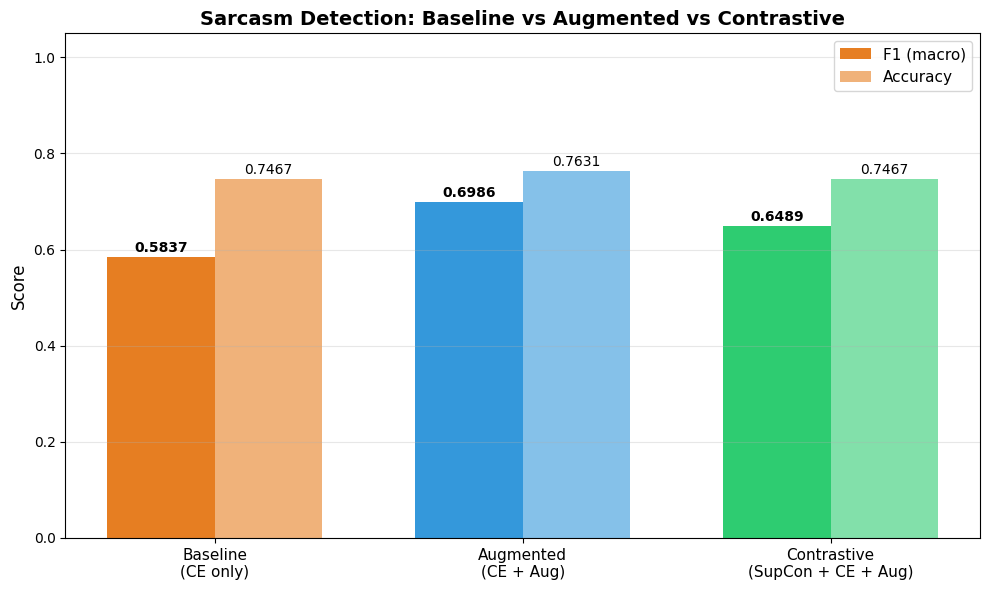


BEST MODEL: Augmented (CE + Aug) — F1 = 0.6986
Improvement over baseline: +0.0653 (11.2%)


In [20]:
# ============================================================
# CELL 18: Final Comparison Bar Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

models = [
    "Baseline\n(CE only)",
    "Augmented\n(CE + Aug)",
    "Contrastive\n(SupCon + CE + Aug)",
]

f1_scores = [
    f1_score(y_true, y_pred_base, average="macro"),
    f1_score(y_true, y_pred_aug,  average="macro"),
    f1_score(y_true, y_pred_con,  average="macro"),
]
acc_scores = [
    accuracy_score(y_true, y_pred_base),
    accuracy_score(y_true, y_pred_aug),
    accuracy_score(y_true, y_pred_con),
]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(
    x - width/2, f1_scores, width,
    label="F1 (macro)",
    color=["#e67e22", "#3498db", "#2ecc71"]
)
bars2 = ax.bar(
    x + width/2, acc_scores, width,
    label="Accuracy",
    color=["#f0b27a", "#85c1e9", "#82e0aa"]
)

# Add value labels on bars
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
        f"{bar.get_height():.4f}", ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
        f"{bar.get_height():.4f}", ha="center", va="bottom",
        fontsize=10
    )

ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Sarcasm Detection: Baseline vs Augmented vs Contrastive",
    fontsize=14, fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Final summary
best_f1 = max(f1_scores)
best_model = models[f1_scores.index(best_f1)]
improvement = f1_scores[2] - f1_scores[0]

print(f"\n{'=' * 60}")
print(f"BEST MODEL: {best_model.replace(chr(10), ' ')} — F1 = {best_f1:.4f}")
print(f"Improvement over baseline: +{improvement:.4f} ({improvement/f1_scores[0]*100:.1f}%)")
print(f"{'=' * 60}")